<a href="https://www.kaggle.com/code/sonawanelalitsunil/jee-dropout-prediction-after-class-12-ml-99-13?scriptVersionId=234374257" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/simulated-dataset-jee-dropout-after-class-12/JEE_Dropout_After_Class_12.csv


## Title: JEE Dropout Prediction After Class 12

#### Description: A simulated dataset analyzing factors influencing students' likelihood of dropping out from the Joint Entrance Examination (JEE) after completing Class 12. The dataset includes variables like academic performance, socio-economic background, study habits, and coaching involvement to predict dropout risk.

## Import dataset

In [2]:
df= pd.read_csv('/kaggle/input/simulated-dataset-jee-dropout-after-class-12/JEE_Dropout_After_Class_12.csv')

In [3]:
df.head()

,jee_main_score,jee_advanced_score,mock_test_score_avg,school_board,class_12_percent,attempt_count,coaching_institute,daily_study_hours,family_income,parent_education,location_type,peer_pressure_level,mental_health_issues,admission_taken,dropout
0,78.95,59.22,59.86,CBSE,70.09,1,FIITJEE,5.4,Low,Upto 10th,Urban,Low,No,No,1
1,70.06,58.75,64.33,State,78.00,1,FIITJEE,5.5,Mid,Upto 10th,Urban,Low,Yes,No,0
2,81.07,37.27,60.83,ICSE,64.36,1,FIITJEE,7.0,Low,PG,Semi-Urban,Medium,Yes,No,1
3,93.32,60.72,69.33,ICSE,73.21,1,FIITJEE,2.1,Low,12th,Semi-Urban,Medium,Yes,Yes,0
4,68.72,77.73,82.37,CBSE,89.02,1,Allen,6.3,Mid,Graduate,Semi-Urban,High,No,Yes,0


In [4]:
df.tail()

,jee_main_score,jee_advanced_score,mock_test_score_avg,school_board,class_12_percent,attempt_count,coaching_institute,daily_study_hours,family_income,parent_education,location_type,peer_pressure_level,mental_health_issues,admission_taken,dropout
4995,71.31,86.82,57.08,State,84.45,1,FIITJEE,4.7,High,PG,Semi-Urban,High,Yes,Yes,0
4996,81.96,34.03,82.85,CBSE,73.02,2,Local,4.7,Mid,PG,Urban,High,Yes,Yes,0
4997,100.00,54.71,83.75,CBSE,77.87,2,NaN,6.3,Mid,PG,Semi-Urban,Medium,Yes,Yes,0
4998,83.31,73.93,57.39,CBSE,62.25,1,Allen,4.0,High,Upto 10th,Urban,Low,No,Yes,0
4999,60.13,76.31,66.15,State,94.90,2,FIITJEE,2.1,Mid,12th,Urban,Low,Yes,No,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   jee_main_score        5000 non-null   float64
 1   jee_advanced_score    5000 non-null   float64
 2   mock_test_score_avg   5000 non-null   float64
 3   school_board          5000 non-null   object 
 4   class_12_percent      5000 non-null   float64
 5   attempt_count         5000 non-null   int64  
 6   coaching_institute    3791 non-null   object 
 7   daily_study_hours     5000 non-null   float64
 8   family_income         5000 non-null   object 
 9   parent_education      5000 non-null   object 
 10  location_type         5000 non-null   object 
 11  peer_pressure_level   5000 non-null   object 
 12  mental_health_issues  5000 non-null   object 
 13  admission_taken       5000 non-null   object 
 14  dropout               5000 non-null   int64  
dtypes: float64(5), int64(

In [6]:
df.describe()

,jee_main_score,jee_advanced_score,mock_test_score_avg,class_12_percent,attempt_count,daily_study_hours,dropout
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,71.961226,65.736404,68.110756,74.957400,1.504600,4.483860,0.207200
std,13.668497,15.909248,11.938849,9.885309,0.500029,1.984723,0.405341
min,26.620000,3.240000,27.490000,50.000000,1.000000,0.000000,0.000000
25%,62.790000,55.017500,60.070000,68.067500,1.000000,3.100000,0.000000
50%,72.190000,65.720000,68.120000,74.940000,2.000000,4.500000,0.000000
75%,81.322500,76.835000,76.110000,81.842500,2.000000,5.900000,0.000000
max,100.000000,100.000000,100.000000,100.000000,2.000000,10.000000,1.000000


In [7]:
df.isnull().sum()

jee_main_score             0
jee_advanced_score         0
mock_test_score_avg        0
school_board               0
class_12_percent           0
attempt_count              0
coaching_institute      1209
daily_study_hours          0
family_income              0
parent_education           0
location_type              0
peer_pressure_level        0
mental_health_issues       0
admission_taken            0
dropout                    0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

jee_main_score          float64
jee_advanced_score      float64
mock_test_score_avg     float64
school_board             object
class_12_percent        float64
attempt_count             int64
coaching_institute       object
daily_study_hours       float64
family_income            object
parent_education         object
location_type            object
peer_pressure_level      object
mental_health_issues     object
admission_taken          object
dropout                   int64
dtype: object

In [10]:
df.shape

(5000, 15)

In [11]:
df.columns

Index(['jee_main_score', 'jee_advanced_score', 'mock_test_score_avg',
       'school_board', 'class_12_percent', 'attempt_count',
       'coaching_institute', 'daily_study_hours', 'family_income',
       'parent_education', 'location_type', 'peer_pressure_level',
       'mental_health_issues', 'admission_taken', 'dropout'],
      dtype='object')

## Data visualizations

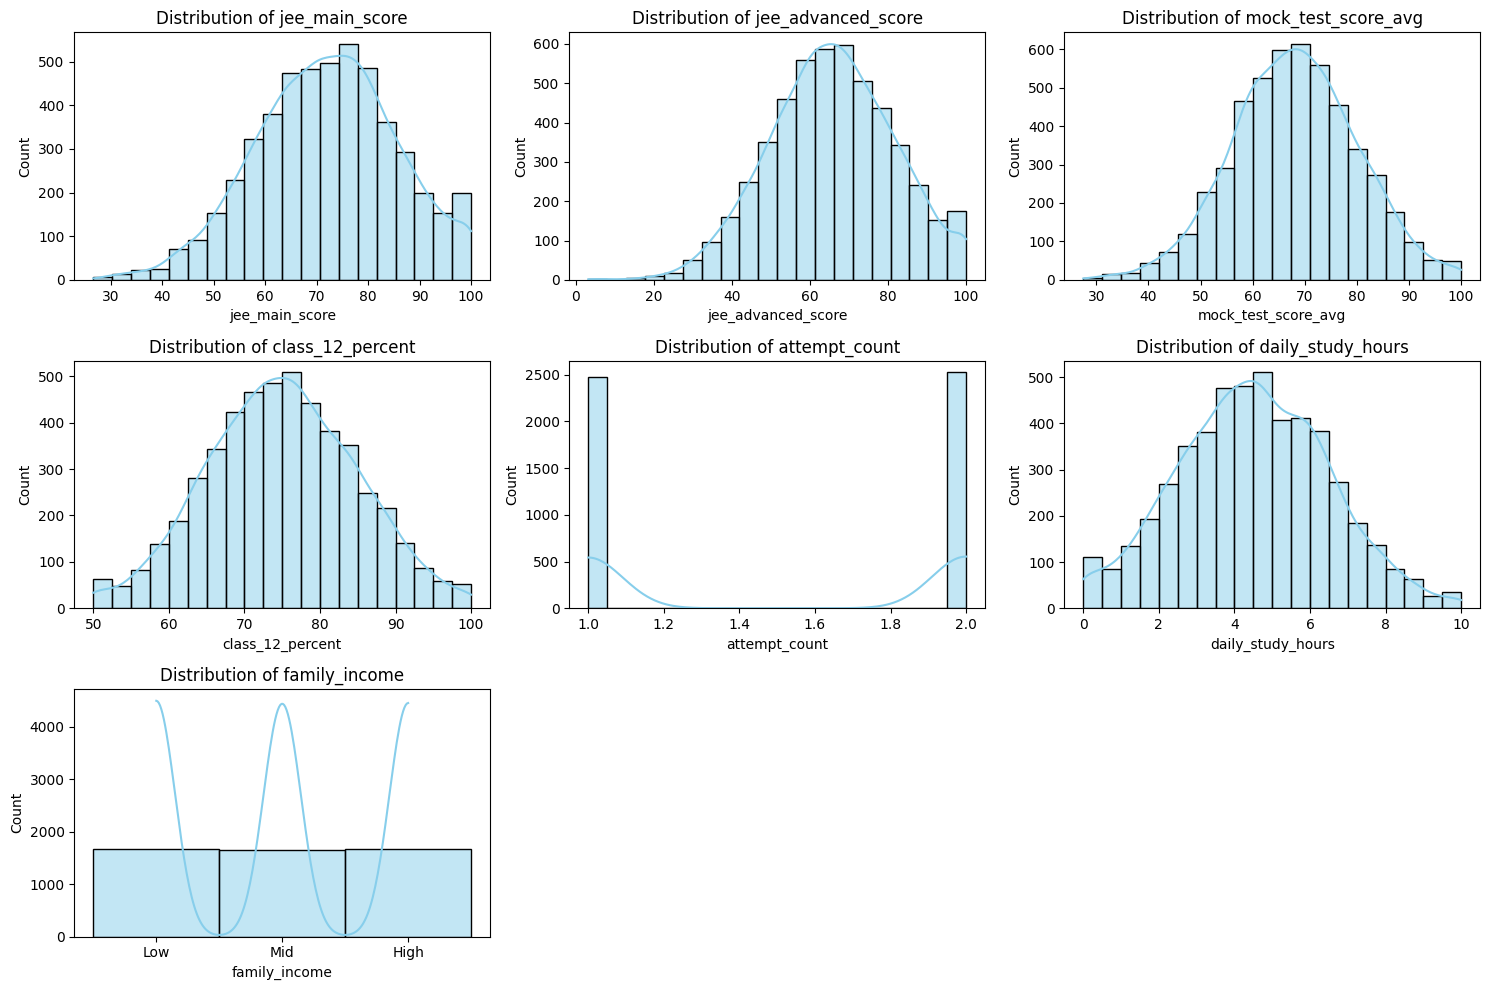

In [12]:
# Plotting the distribution of continuous variables

continuous_cols = ['jee_main_score', 'jee_advanced_score', 'mock_test_score_avg', 
                   'class_12_percent', 'attempt_count', 'daily_study_hours', 'family_income']

plt.figure(figsize=(15, 10))
for i, col in enumerate(continuous_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, color='skyblue', bins=20)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
plt.show()


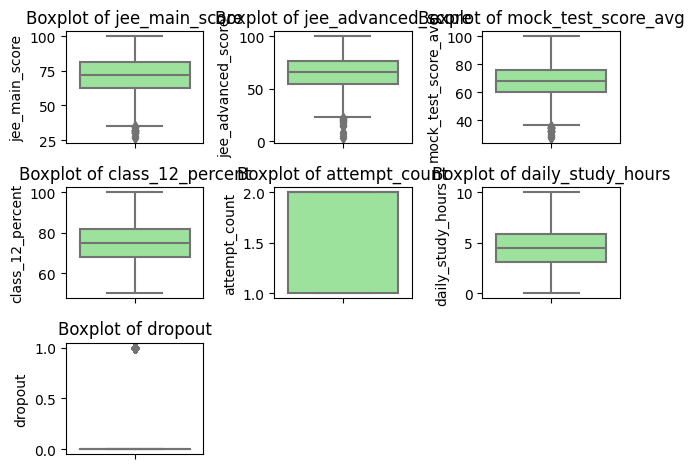

In [13]:
# Identify the continuous columns
continuous_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Create the boxplots for each continuous column
for i, col in enumerate(continuous_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color='lightgreen')  # Use y for vertical boxplot
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()


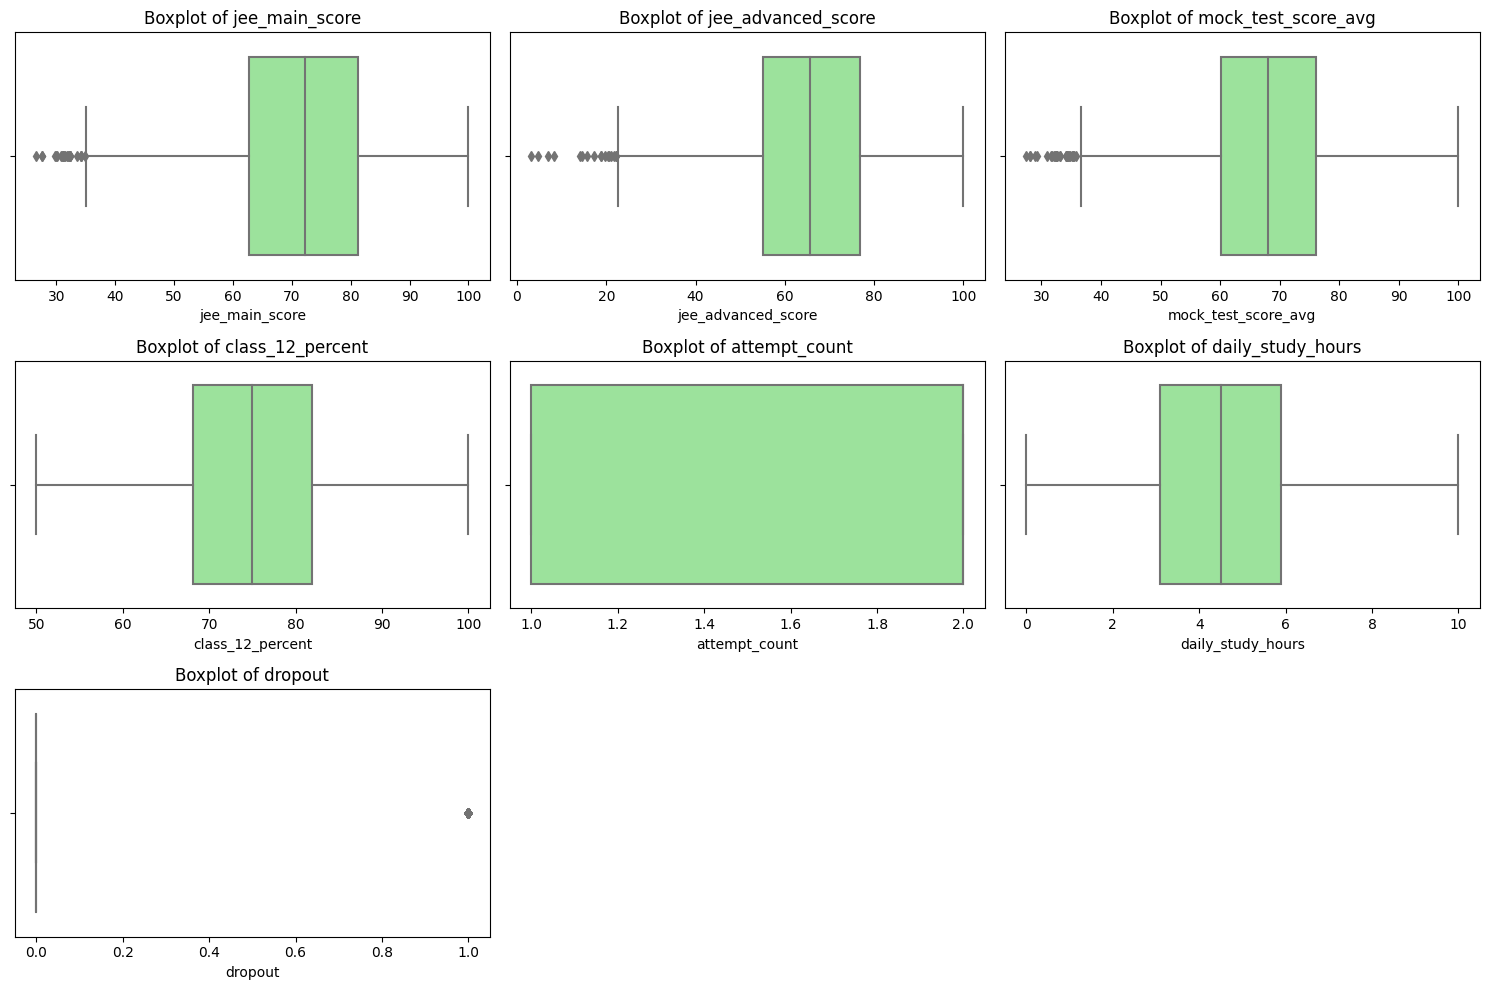

In [14]:
# Ensure that continuous_cols only includes numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
plt.show()


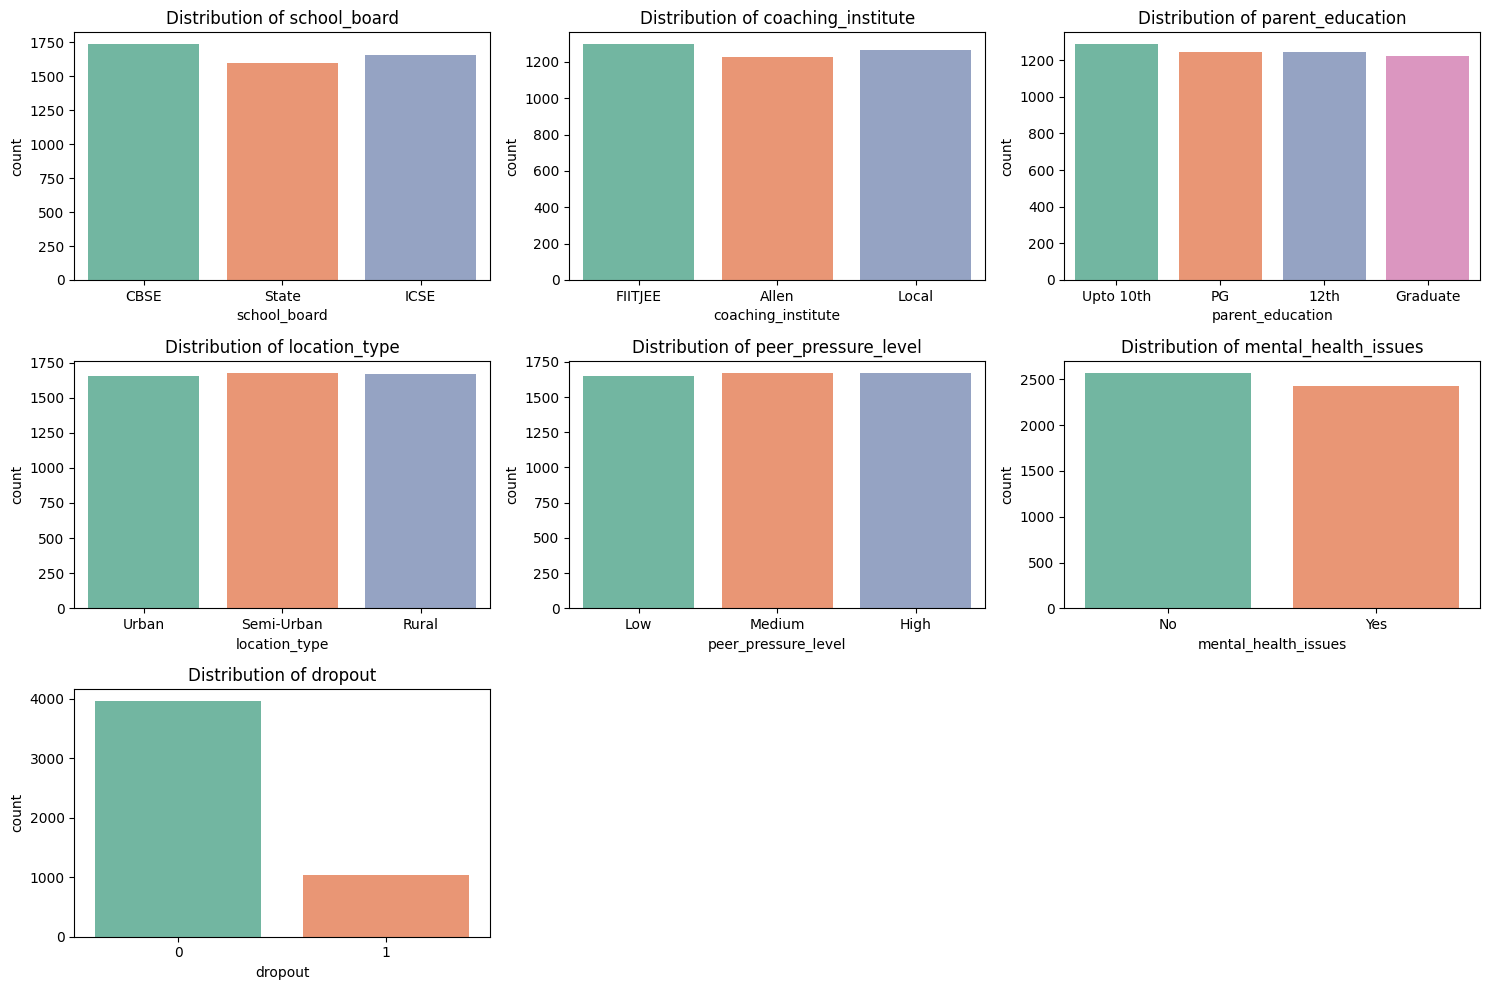

In [15]:
# Categorical columns
categorical_cols = ['school_board', 'coaching_institute', 'parent_education', 
                    'location_type', 'peer_pressure_level', 'mental_health_issues', 'dropout']

plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=df[col], palette='Set2')
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
plt.show()


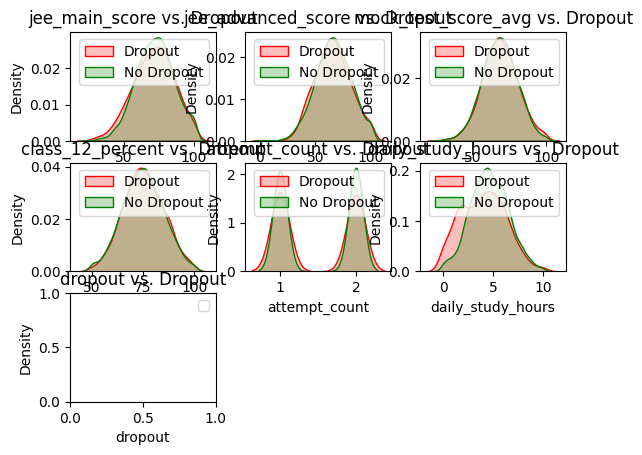

In [16]:
# Identify the continuous columns
continuous_cols = df.select_dtypes(include=['float64', 'int64']).columns

for i, col in enumerate(continuous_cols, 1):
    plt.subplot(3, 3, i)
    sns.kdeplot(df[df['dropout'] == 1][col], shade=True, label='Dropout', color='red')
    sns.kdeplot(df[df['dropout'] == 0][col], shade=True, label='No Dropout', color='green')
    plt.title(f'{col} vs. Dropout')
    plt.legend()


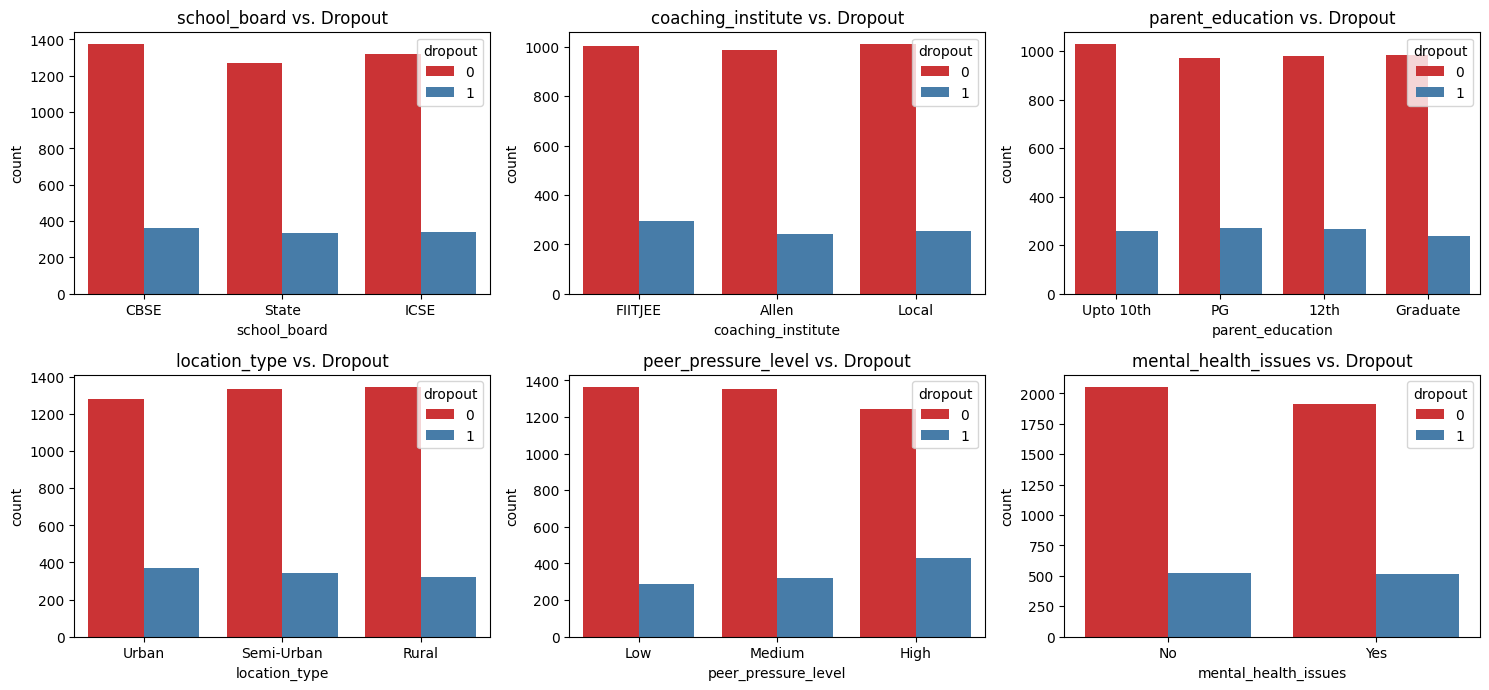

In [17]:
# Categorical features vs. dropout
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols[:-1], 1):  # Exclude 'dropout' column
    plt.subplot(3, 3, i)
    sns.countplot(x=col, hue='dropout', data=df, palette='Set1')
    plt.title(f'{col} vs. Dropout')
    plt.tight_layout()
plt.show()


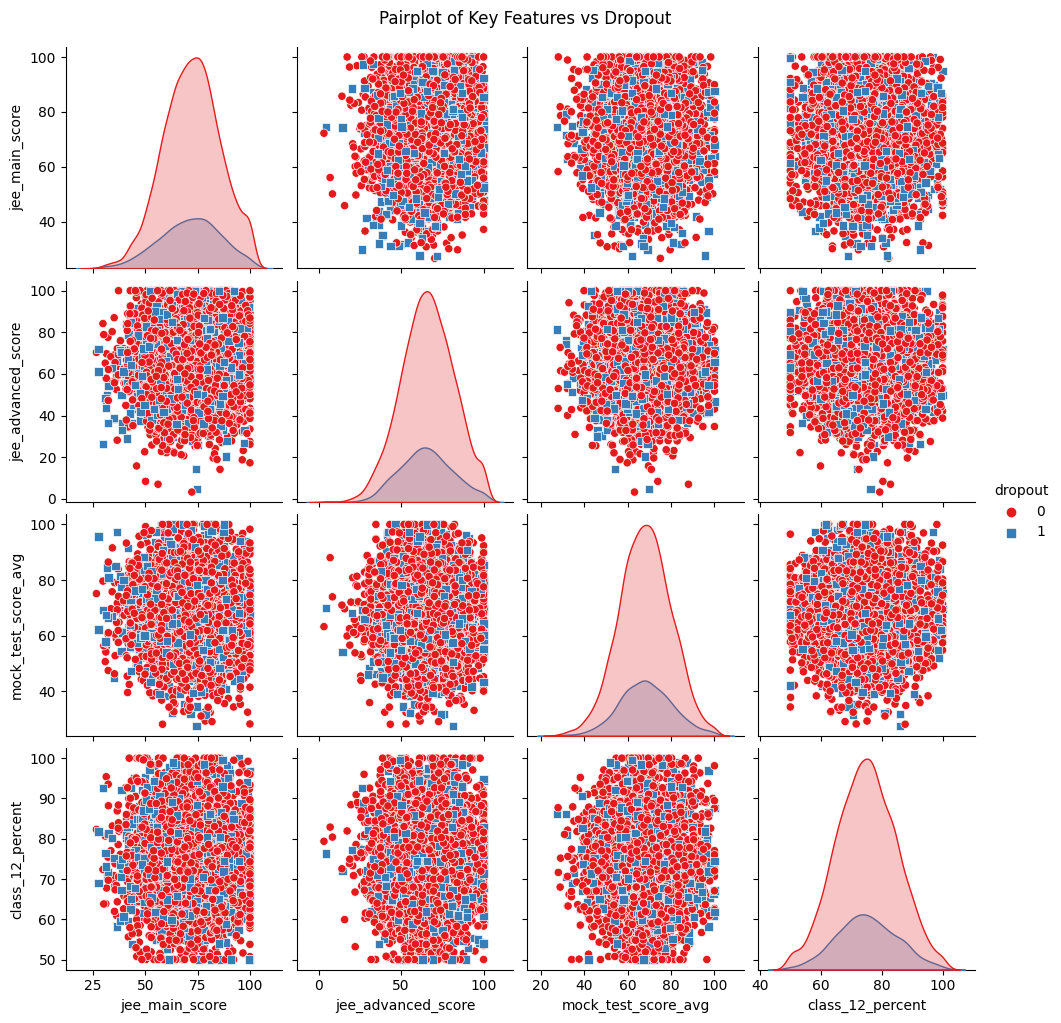

In [18]:
# Pairplot of important continuous variables
sns.pairplot(df[['jee_main_score', 'jee_advanced_score', 'mock_test_score_avg', 'class_12_percent', 'dropout']], 
             hue='dropout', palette='Set1', markers=["o", "s"])
plt.suptitle('Pairplot of Key Features vs Dropout', y=1.02)
plt.show()


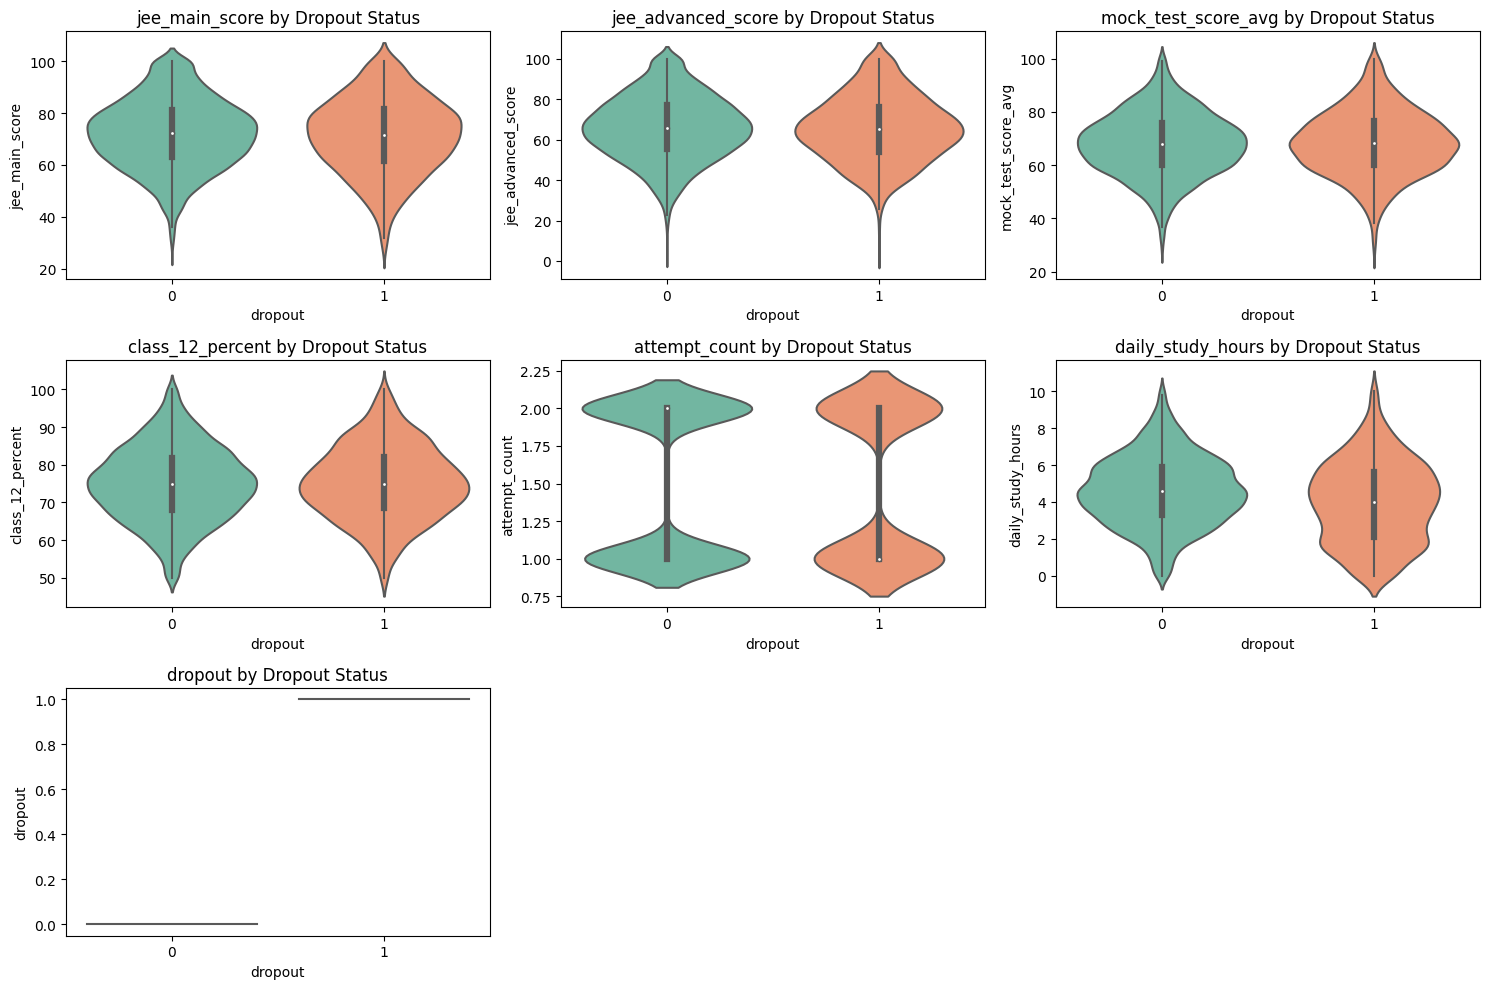

In [19]:
# Violin plots for continuous features based on dropout status
plt.figure(figsize=(15, 10))
for i, col in enumerate(continuous_cols, 1):
    plt.subplot(3, 3, i)
    sns.violinplot(x='dropout', y=col, data=df, palette='Set2')
    plt.title(f'{col} by Dropout Status')
    plt.tight_layout()
plt.show()


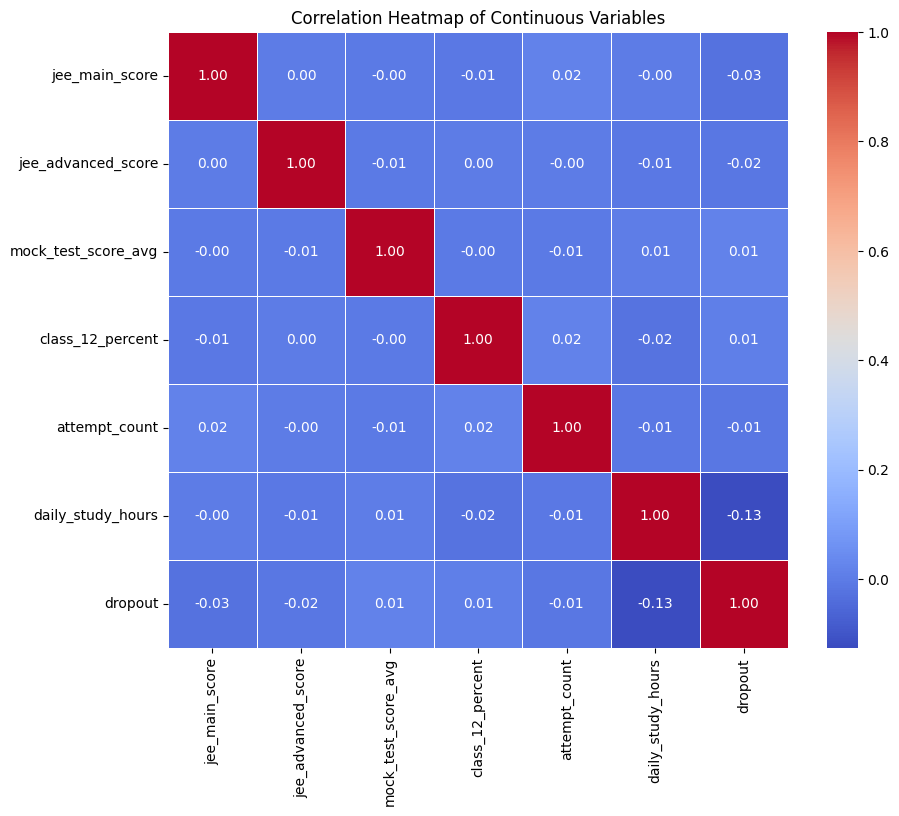

In [20]:
# Exclude categorical columns from correlation calculation
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Continuous Variables')
plt.show()


## Predictive modeling

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

In [22]:
le = LabelEncoder()

In [23]:
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])


In [24]:
X = df.drop('dropout', axis=1)  # Assuming 'dropout' is the target column
y = df['dropout']


In [25]:
# Step 2: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [26]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Naive Bayes': GaussianNB()
}

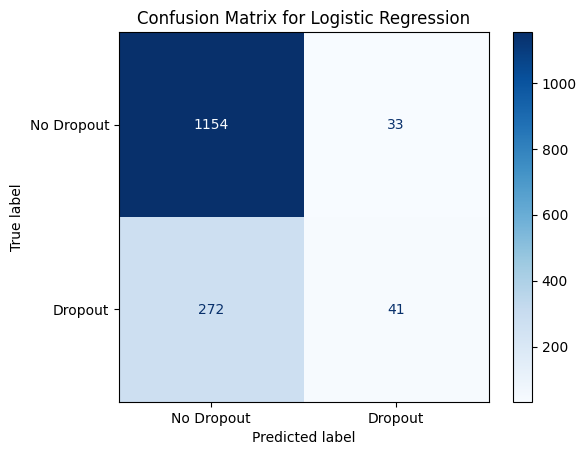

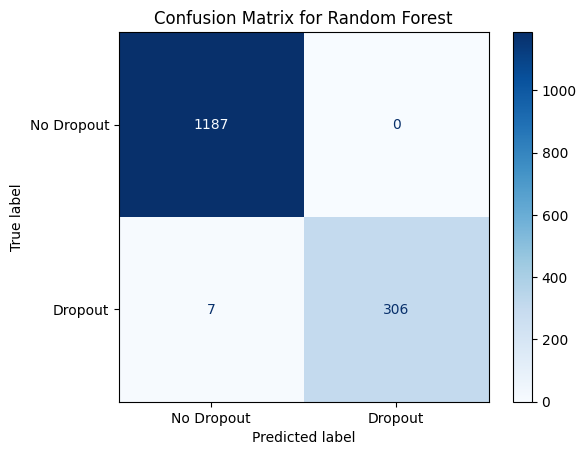

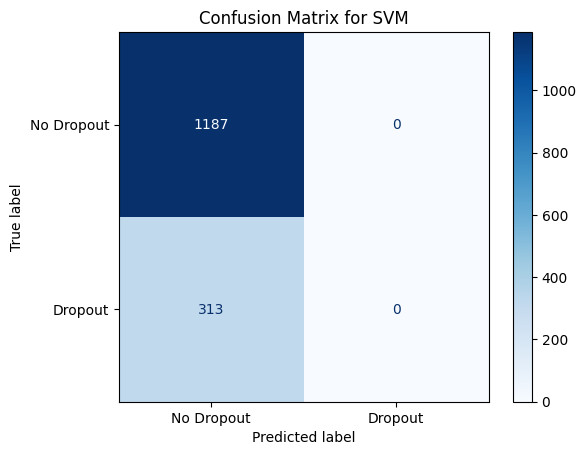

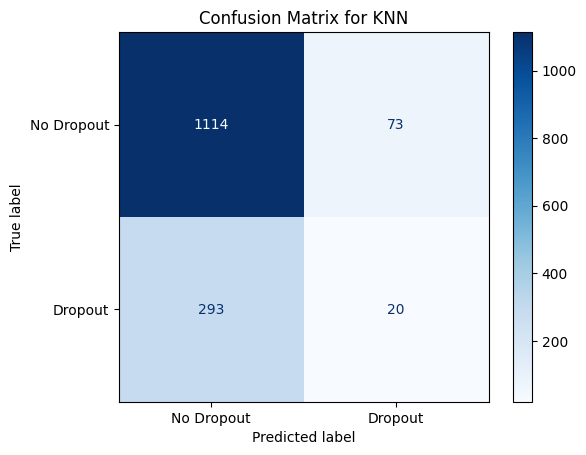

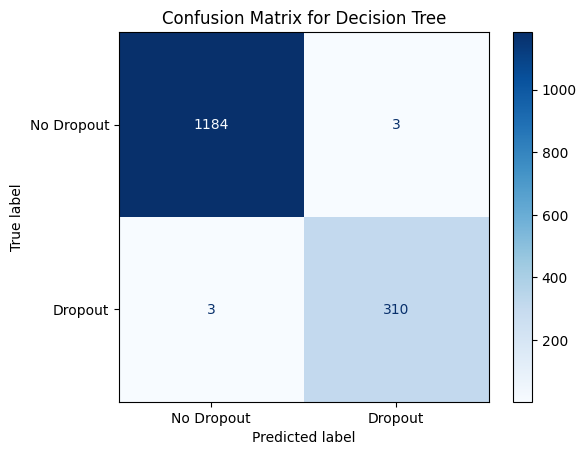

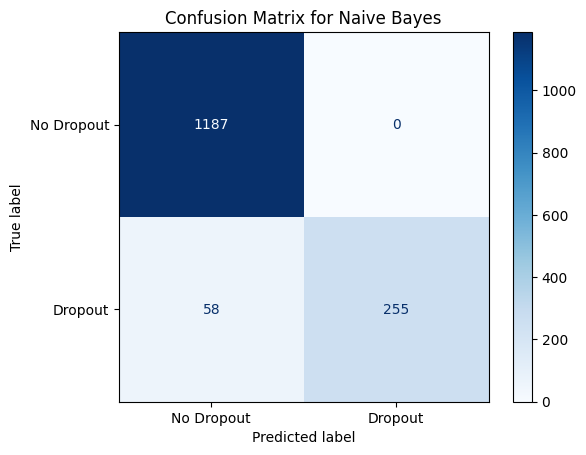

In [27]:
# Step 4: Train and evaluate models
results = {}
for model_name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_percentage = accuracy * 100
    
    # Store results
    results[model_name] = accuracy_percentage
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Dropout', 'Dropout'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {model_name}')
    plt.show()

In [28]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy (%)'])
print(results_df)

                 Model  Accuracy (%)
0  Logistic Regression     79.666667
1        Random Forest     99.533333
2                  SVM     79.133333
3                  KNN     75.600000
4        Decision Tree     99.600000
5          Naive Bayes     96.133333


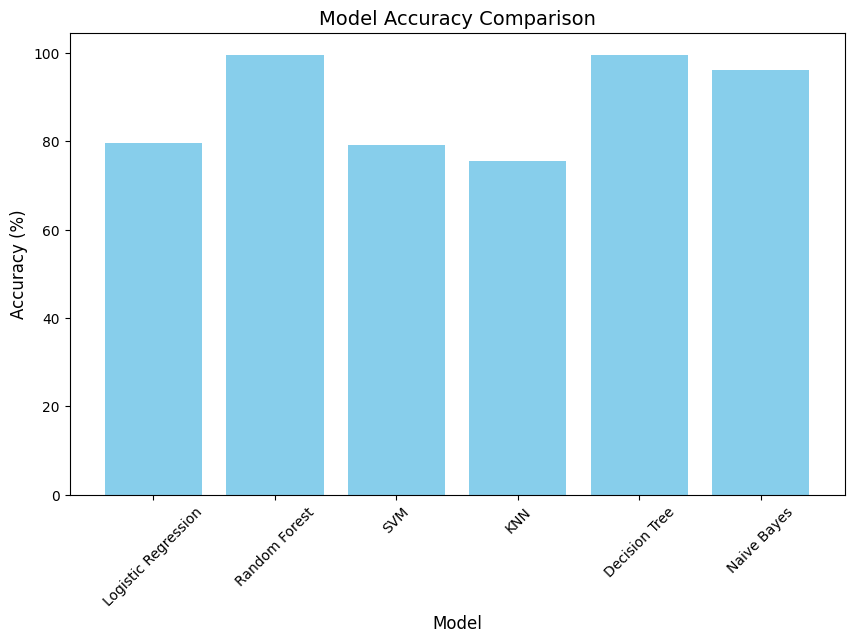

In [29]:
models = ['Logistic Regression', 'Random Forest', 'SVM', 'KNN', 'Decision Tree', 'Naive Bayes']
accuracy = [79.666667, 99.400000, 79.133333, 75.600000, 99.533333, 96.133333]

# Create the bar chart
plt.figure(figsize=(10, 6))
plt.bar(models, accuracy, color='skyblue')

# Add title and labels
plt.title('Model Accuracy Comparison', fontsize=14)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)

# Display the chart
plt.xticks(rotation=45)
plt.show()

## Thank you..pls upvote!!!